# IMPORTACIONES Y CONFIGURACIÓN CSV 

In [1]:
#importamos librerías 

import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt


from src import soporte_analisis as sp_analisis


In [2]:
#importamos librerías para el preprocesamiento de datos

import warnings 
warnings.filterwarnings('ignore', category=FutureWarning)

In [3]:
#configuramos pandas para mostrar todas las columnas del dataframe

pd.set_option('display.max_columns', None)

# FASE 2 - ANÁLISIS ESTADÍSTICO 



Este jupyter notebook contiene la fase 2 en la que se analizan con mayor profundidad las columnas numéricas y categóricas del csv que ya une los dos csvs de inicio. Se han realizado estadísticas descriptivas, identificación de outliers, de correlación y la frecuencia. 

In [ ]:
#LECTURA CSV UNIDO CON LOS DATOS LIMPIOS
df_unido_limpio = pd.read_csv("files/df_unido_limpio.csv")

In [5]:
df_unido_limpio.head(10)

,loyalty_number,year,month,flights_booked,flights_with_companions,total_flights,distance,points_accumulated,points_redeemed,dollar_cost_points_redeemed,province,city,postal_code,gender,education,salary,marital_status,loyalty_card,clv,enrollment_type,enrollment_year,enrollment_month,cancellation_year,cancellation_month,canceled_loyalty_card
0,100018,2017,1,3,0,3,1521,152.0,0,0,Alberta,Edmonton,T9G 1W3,Female,Bachelor,92552.0,Married,Aurora,7919.20,Standard,2016,8,NaN,NaN,0
1,100102,2017,1,10,4,14,2030,203.0,0,0,Ontario,Toronto,M1R 4K3,Male,College,66888.5,Single,Nova,2887.74,Standard,2013,3,NaN,NaN,0
2,100140,2017,1,6,0,6,1200,120.0,0,0,British Columbia,Dawson Creek,U5I 4F1,Female,College,66888.5,Divorced,Nova,2838.07,Standard,2016,7,NaN,NaN,0
3,100214,2017,1,0,0,0,0,0.0,0,0,British Columbia,Vancouver,V5R 1W3,Male,Bachelor,63253.0,Married,Star,4170.57,Standard,2015,8,NaN,NaN,0
4,100272,2017,1,0,0,0,0,0.0,0,0,Ontario,Toronto,P1L 8X8,Female,Bachelor,91163.0,Divorced,Star,6622.05,Standard,2014,1,NaN,NaN,0
5,100301,2017,1,0,0,0,0,0.0,0,0,Ontario,Toronto,P1J 8T7,Male,Bachelor,70323.0,Divorced,Nova,48356.96,Standard,2013,9,NaN,NaN,0
6,100364,2017,1,0,0,0,0,0.0,0,0,Saskatchewan,Regina,S6J 3G0,Male,Bachelor,76849.0,Married,Nova,5143.88,Standard,2015,5,NaN,NaN,0
7,100380,2017,1,0,0,0,0,0.0,0,0,Quebec,Montreal,H2T 9K8,Female,Bachelor,69695.0,Single,Star,2465.62,Standard,2012,10,NaN,NaN,0
8,100428,2017,1,6,0,6,606,60.0,0,0,British Columbia,Vancouver,V6E 3D9,Male,Bachelor,63478.0,Married,Aurora,5845.43,Standard,2012,8,NaN,NaN,0
9,100504,2017,1,0,0,0,0,0.0,0,0,Ontario,Sudbury,M5V 1G5,Female,Bachelor,75638.0,Divorced,Nova,8807.61,Standard,2017,7,2018.0,3.0,1


In [6]:
df_unido_limpio.info()

<class 'pandas.DataFrame'>
RangeIndex: 403760 entries, 0 to 403759
Data columns (total 25 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   loyalty_number               403760 non-null  int64  
 1   year                         403760 non-null  int64  
 2   month                        403760 non-null  int64  
 3   flights_booked               403760 non-null  int64  
 4   flights_with_companions      403760 non-null  int64  
 5   total_flights                403760 non-null  int64  
 6   distance                     403760 non-null  int64  
 7   points_accumulated           403760 non-null  float64
 8   points_redeemed              403760 non-null  int64  
 9   dollar_cost_points_redeemed  403760 non-null  int64  
 10  province                     403760 non-null  str    
 11  city                         403760 non-null  str    
 12  postal_code                  403760 non-null  str    
 13  gender    

# 1. ANÁLISIS DE VARIABLES NUMÉRICAS 

In [ ]:
#Como vamos a empezar a trabajar con las variables numéricas, identifico qué columnas son numéricas y cuáles no para poder analizarlas posteriormente.
df_unido_limpio.select_dtypes(include='number').columns

Index(['loyalty_number', 'year', 'month', 'flights_booked',
       'flights_with_companions', 'total_flights', 'distance',
       'points_accumulated', 'points_redeemed', 'dollar_cost_points_redeemed',
       'salary', 'clv', 'enrollment_year', 'enrollment_month',
       'cancellation_year', 'cancellation_month', 'canceled_loyalty_card'],
      dtype='str')

In [8]:
#Agrupamos por las columnas numéricas para obtener estadísticas descriptivas de cada una de ellas.
df_unido_limpio.describe(include='number').T

,count,mean,std,min,25%,50%,75%,max
loyalty_number,403760.0,549875.383713,258961.514684,100018.00,326699.00,550598.00,772152.00,999986.00
year,403760.0,2017.500352,0.500000,2017.00,2017.00,2018.00,2018.00,2018.00
month,403760.0,6.501335,3.451982,1.00,4.00,7.00,10.00,12.00
flights_booked,403760.0,4.134050,5.230064,0.00,0.00,1.00,8.00,21.00
flights_with_companions,403760.0,1.036569,2.080472,0.00,0.00,0.00,1.00,11.00
total_flights,403760.0,5.170619,6.526858,0.00,0.00,1.00,10.00,32.00
distance,403760.0,1214.460979,1434.098521,0.00,0.00,525.00,2342.00,6293.00
points_accumulated,403760.0,124.263761,146.696179,0.00,0.00,53.00,240.00,676.50
points_redeemed,403760.0,30.838587,125.758002,0.00,0.00,0.00,0.00,876.00
dollar_cost_points_redeemed,403760.0,2.495973,10.172033,0.00,0.00,0.00,0.00,71.00


In [9]:
#Seleccionamos las columnas numéricas relevantes para el análisis estadístico.
cols_relevantes = [
    'flights_booked', 'total_flights', 'distance',
    'points_accumulated', 'dollar_cost_points_redeemed',
    'salary', 'clv'
]
#Calculamos las estadísticas descriptivas para las columnas numéricas relevantes.
estadisticas = df_unido_limpio[cols_relevantes].agg(['mean', 'median', 'std', 'min', 'max'])
#Calculamos la moda para cada columna numérica relevante y la añadimos al dataframe de estadísticas.
estadisticas.loc['mode'] = df_unido_limpio[cols_relevantes].mode().iloc[0]

estadisticas

,flights_booked,total_flights,distance,points_accumulated,dollar_cost_points_redeemed,salary,clv
mean,4.134050,5.170619,1214.460979,124.263761,2.495973,76210.113632,7990.864857
median,1.000000,1.000000,525.000000,53.000000,0.000000,66888.500000,5776.340000
std,5.230064,6.526858,1434.098521,146.696179,10.172033,30495.444375,6863.317160
min,0.000000,0.000000,0.000000,0.000000,0.000000,9081.000000,1898.010000
max,21.000000,32.000000,6293.000000,676.500000,71.000000,407228.000000,83325.380000
mode,0.000000,0.000000,0.000000,0.000000,0.000000,66888.500000,8564.770000


El análisis de los registros muestra la existencia de clientes sin actividad de vuelo en determinados periodos, lo que puede indicar falta de engagement o inactividad dentro del programa de fidelización. Además, se observa una alta variabilidad en variables como el salario y el CLV, lo que sugiere una base de clientes heterogénea. Es importante destacar que el CLV no depende únicamente de la actividad mensual, sino del valor acumulado del cliente. Finalmente, la presencia de múltiples valores cero requiere validación para distinguir entre ausencia de actividad y posibles problemas de calidad de datos.

In [10]:
#IDENTIFICAMOS VALORES ATÍPICOS NUMÉRICOS 

In [11]:
#llamamos a la función para ver cuántos outliers hay en cada columna numérica
sp_analisis.outliers_iqr(df_unido_limpio, [ 'flights_booked',
       'flights_with_companions', 'total_flights', 'distance',
       'points_accumulated', 'points_redeemed', 'dollar_cost_points_redeemed',
       'salary', 'clv'])


**************************************************
******* ANALIZANDO COLUMNA: FLIGHTS_BOOKED *******
**************************************************
  > Límites teóricos: [-12.0 a 20.0]
  > Total de outliers: 528
  > Porcentaje sobre el total: 0.13%
--------------------------------------------------

**************************************************
** ANALIZANDO COLUMNA: FLIGHTS_WITH_COMPANIONS ***
**************************************************
  > Límites teóricos: [-1.5 a 2.5]
  > Total de outliers: 71560
  > Porcentaje sobre el total: 17.72%
--------------------------------------------------

**************************************************
******* ANALIZANDO COLUMNA: TOTAL_FLIGHTS ********
**************************************************
  > Límites teóricos: [-15.0 a 25.0]
  > Total de outliers: 1984
  > Porcentaje sobre el total: 0.49%
--------------------------------------------------

**************************************************
********** ANALIZANDO COLUMN

{}

El análisis de outliers muestra que la mayoría de variables operativas (como vuelos o distancia) presentan pocos valores atípicos, lo que indica un comportamiento relativamente homogéneo. Sin embargo, variables relacionadas con el comportamiento del cliente y el valor económico, como flights_with_companions, points_redeemed, salary y CLV, presentan una mayor proporción de outliers. En particular, la alta concentración de valores cero en algunas variables provoca que cualquier valor positivo sea considerado atípico, lo que refleja patrones de uso específicos más que errores en los datos. Además, los outliers en CLV sugieren la existencia de clientes de alto valor que podrían ser estratégicos para la empresa.

In [12]:
#CORRELACCIÓN ENTRE VARIABLES NUMÉRICAS

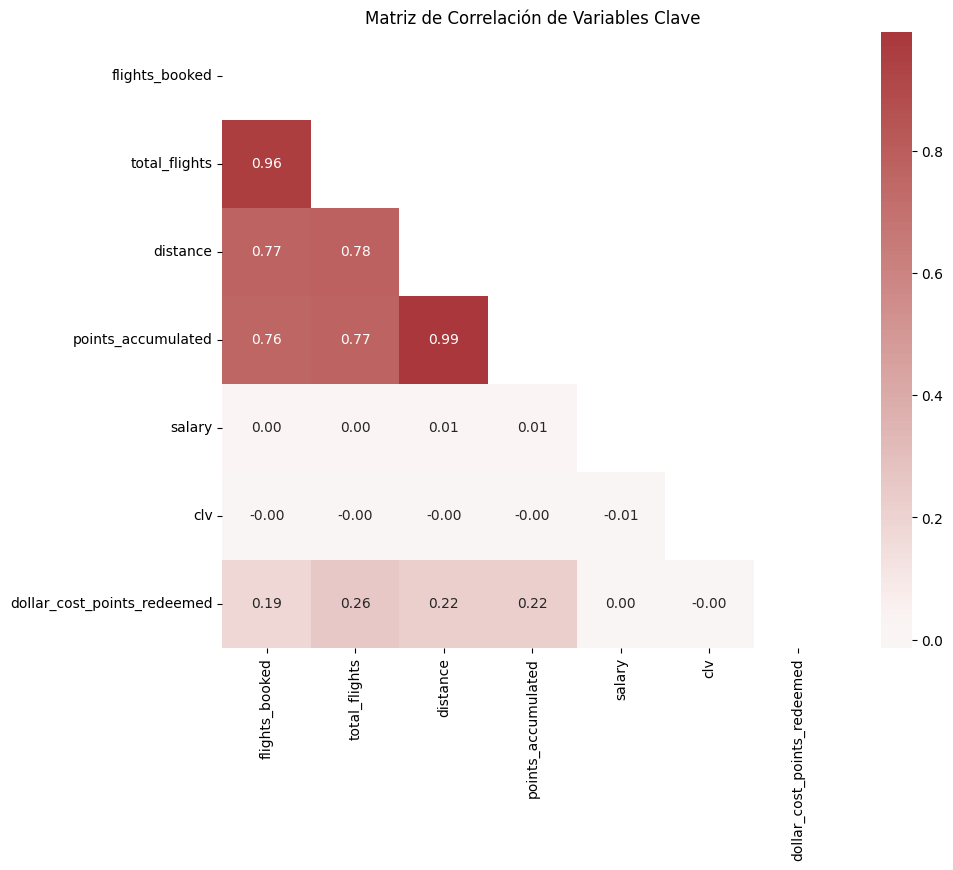

In [ ]:
# 1. Seleccionamos las variables numéricas que tienen sentido correlacionar
# Excluimos loyalty_number, años y meses.
cols_analisis = [
    'flights_booked', 'total_flights', 'distance', 
    'points_accumulated', 'salary', 'clv', 'dollar_cost_points_redeemed'
]

# 2. Llamamos a la función de soporte
matriz = sp_analisis.matriz_correlacion(df_unido_limpio, cols_analisis)

# 3. Dibujamos el Heatmap con Seaborn
plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(matriz, dtype=bool)) # Máscara para ver solo la mitad (opcional)

sns.heatmap(matriz, 
            annot=True,       # Muestra los números
            fmt=".2f",        # Dos decimales
            cmap='vlag',  
            center=0, 
            mask=mask)

plt.title('Matriz de Correlación de Variables Clave')
plt.show()

Este heatmap nos indica que las mayores correlacciones son:
    - Total flights y flights booked: cuantos más vuelos reservados más veces habrá volado ese cliente
    - Points accumulated y distance: observamos que según la distancia se dan los puntos
También hay correlacciones menores pero significativas:
    - Distancia y Points accumulated con Flights booked y total flights: cuantos más vuelos realizados más distancia y más puntos acumulados. 
También hay relaciones sin ninguna correlacción o sin apenas correlacción. 

# ANÁLISIS DE VARIABLES CATEGÓRICAS 

In [ ]:
#Identifico las columnas categóricas para analizarlas posteriormente.
df_unido_limpio.select_dtypes(exclude='number').columns

Index(['province', 'city', 'postal_code', 'gender', 'education',
       'marital_status', 'loyalty_card', 'enrollment_type'],
      dtype='str')

In [15]:
# 1. Definimos las variables categóricas relevantes
cols_categoricas = ['province', 'city', 'postal_code', 'gender', 'education',
       'marital_status', 'loyalty_card', 'enrollment_type'
]

# 2. Llamamos a la función
sp_analisis.distribucion_categoricas(df_unido_limpio, cols_categoricas)


=========== DISTRIBUCIÓN DE: PROVINCE ============
                      Recuento  Porcentaje (%)
province                                      
Ontario                 130258           32.26
British Columbia        106442           26.36
Quebec                   79573           19.71
Alberta                  23360            5.79
Manitoba                 15900            3.94
New Brunswick            15352            3.80
Nova Scotia              12507            3.10
Saskatchewan              9861            2.44
Newfoundland              6244            1.55
Yukon                     2679            0.66
Prince Edward Island      1584            0.39
--------------------------------------------------

============= DISTRIBUCIÓN DE: CITY ==============
                Recuento  Porcentaje (%)
city                                    
Toronto            80775           20.01
Vancouver          62314           15.43
Montreal           49687           12.31
Winnipeg           15900     

El análisis exploratorio revela que la mayoría de los clientes presenta baja actividad de vuelo y escaso uso del sistema de recompensas, lo que sugiere oportunidades de mejora en engagement. Sin embargo, existe un segmento reducido de clientes de alto valor (alto CLV) que resulta clave para el negocio. Además, la base de clientes se concentra geográficamente en grandes provincias y ciudades, y presenta una distribución socioeconómica diversa. Estos hallazgos permiten identificar oportunidades de segmentación y optimización de estrategias de fidelización.